##### **Linear Regression using Stochastic Gradient Descent**

##### Dataset  https://www.kaggle.com/competitions/boston-housing/data

In [258]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [259]:
data_overview={
"crim":  "per capita crime rate by town.",
"zn" : "proportion of residential land zoned for lots over 25,000 sq.ft.",
"indus" : "proportion of non-retail business acres per town.",
"chas" : "Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).",
"nox" : "nitrogen oxides concentration (parts per 10 million).",
"rm" : "average number of rooms per dwelling.",
"age" : "proportion of owner-occupied units built prior to 1940.",
"dis" : "weighted mean of distances to five Boston employment centres.",
"rad" : "index of accessibility to radial highways.",
"tax" : "full-value property-tax rate per $10,000.",
"ptratio" : "pupil-teacher ratio by town.",
"black" : "1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town.",
"lstat": "lower status of the population (percent).",
"medv" : "median value of owner-occupied homes in $1000s"
}

def tell_me_about(field):
    return data_overview[field]

In [260]:
tell_me_about("medv")

'median value of owner-occupied homes in $1000s'

In [261]:
train_df=pd.read_csv('data/train.csv')
train_df.head()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


In [262]:
train_df.columns

Index(['ID', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad',
       'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='str')

In [263]:
# fe_columns=[ 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv']
# ID is usually not needed so we ignore that

## Part 1 (Basic EDA)

In [264]:
train_df.describe()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,250.951952,3.360341,10.689189,11.293483,0.060060,0.557144,6.265619,68.226426,3.709934,9.633634,409.279279,18.448048,359.466096,12.515435,22.768769
std,147.859438,7.352272,22.674762,6.998123,0.237956,0.114955,0.703952,28.133344,1.981123,8.742174,170.841988,2.151821,86.584567,7.067781,9.173468
min,1.000000,0.006320,0.000000,0.740000,0.000000,0.385000,3.561000,6.000000,1.129600,1.000000,188.000000,12.600000,3.500000,1.730000,5.000000
25%,123.000000,0.078960,0.000000,5.130000,0.000000,0.453000,5.884000,45.400000,2.122400,4.000000,279.000000,17.400000,376.730000,7.180000,17.400000
50%,244.000000,0.261690,0.000000,9.900000,0.000000,0.538000,6.202000,76.700000,3.092300,5.000000,330.000000,19.000000,392.050000,10.970000,21.600000
75%,377.000000,3.678220,12.500000,18.100000,0.000000,0.631000,6.595000,93.800000,5.116700,24.000000,666.000000,20.200000,396.240000,16.420000,25.000000
max,506.000000,73.534100,100.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,21.200000,396.900000,37.970000,50.000000


In [265]:
train_df.info()
## everything is numeric and non null

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       333 non-null    int64  
 1   crim     333 non-null    float64
 2   zn       333 non-null    float64
 3   indus    333 non-null    float64
 4   chas     333 non-null    int64  
 5   nox      333 non-null    float64
 6   rm       333 non-null    float64
 7   age      333 non-null    float64
 8   dis      333 non-null    float64
 9   rad      333 non-null    int64  
 10  tax      333 non-null    int64  
 11  ptratio  333 non-null    float64
 12  black    333 non-null    float64
 13  lstat    333 non-null    float64
 14  medv     333 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 39.2 KB


In [266]:
train_df.shape

(333, 15)

In [267]:
def basic_summary(df):
    summary_info ={
        "missing_values" : df.isnull().sum(),
        "dtypes" : df.dtypes, 
        "stats" : df.describe().T
    }
    print(summary_info)

In [268]:
basic_summary(train_df)

{'missing_values': ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64, 'dtypes': ID           int64
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object, 'stats':          count        mean         std        min        25%        50%  \
ID       333.0  250.951952  147.859438    1.00000  123.00000  244.00000   
crim     333.0    3.360341    7.352272    0.00632    0.07896    0.26169   
zn       333.0   10.689189   22.674762    0.00000    0.00000    0.00000   
indus    333.0   11.293483    6.998123    0.74000    5.13000    9.90000   
chas     333.0    0.060060    0.237956    0.00000    0.00000    0.00000   
nox

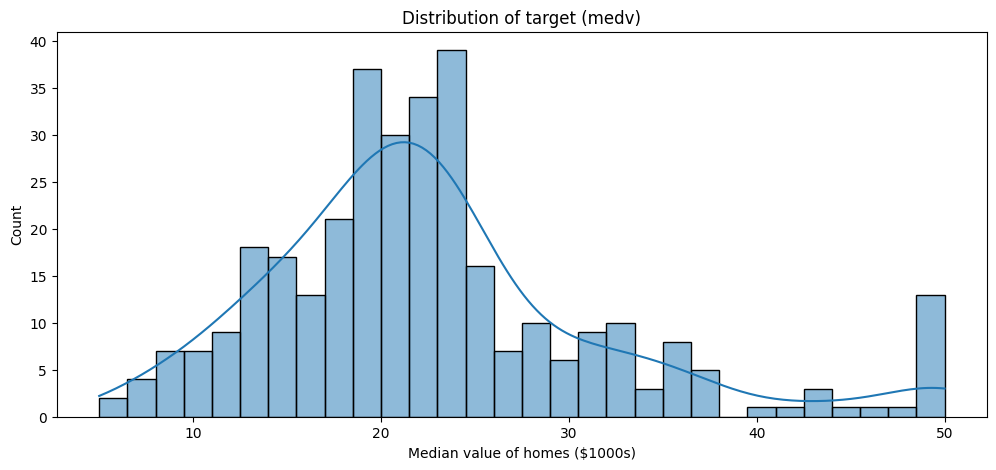

In [269]:
plt.figure(figsize=(12,5))
sns.histplot(train_df['medv'], kde=True, bins=30)
plt.title('Distribution of target (medv)')
plt.xlabel('Median value of homes ($1000s)')
plt.ylabel('Count')
plt.show()

## This is almost normalLY distributed 

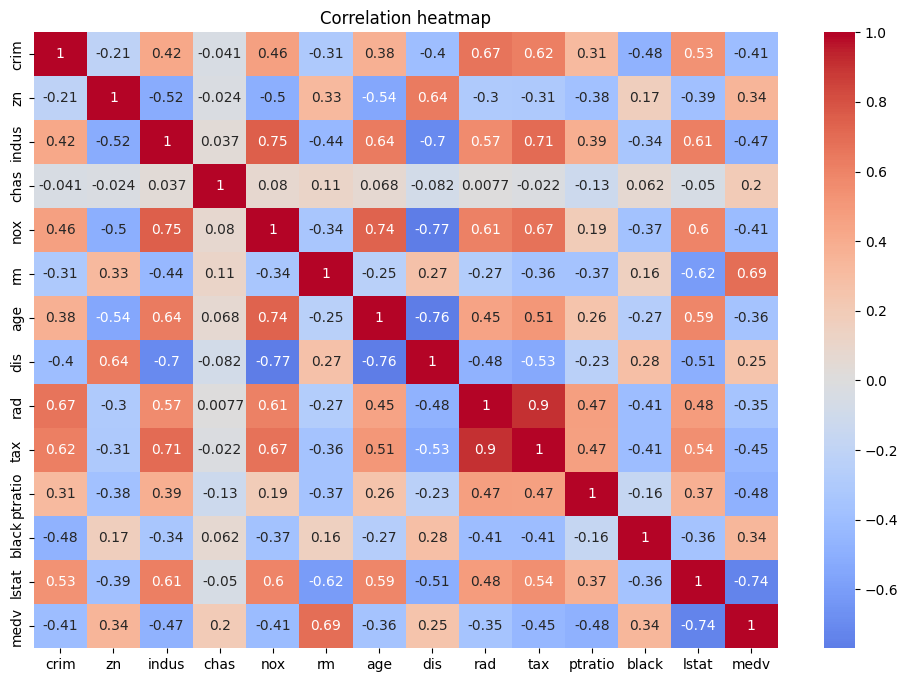

In [270]:
plt.figure(figsize=(12,8))
corr = train_df.drop(columns='ID').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

## Most of the columns are highly correlated with other variables 

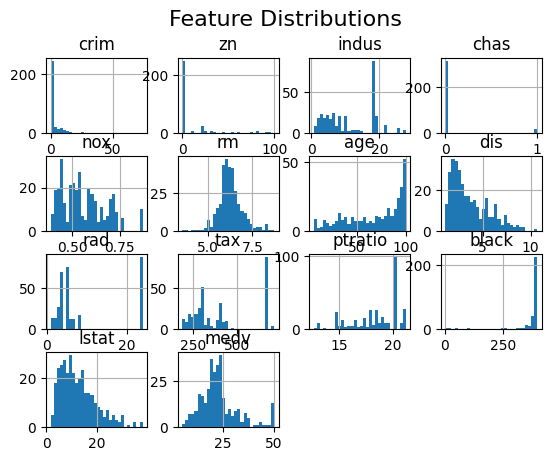

In [271]:
# plt.figure(figsize=(15,10))
train_df.drop(columns='ID').hist(bins=30)
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()

In [272]:
numeric_cols=train_df.drop(columns=['ID', 'chas', 'medv']).columns

# chas is categorical column having only 0, 1 
# ID doesn't influence anything
# medv is the output/target variable 

In [273]:
tell_me_about("chas")

'Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).'

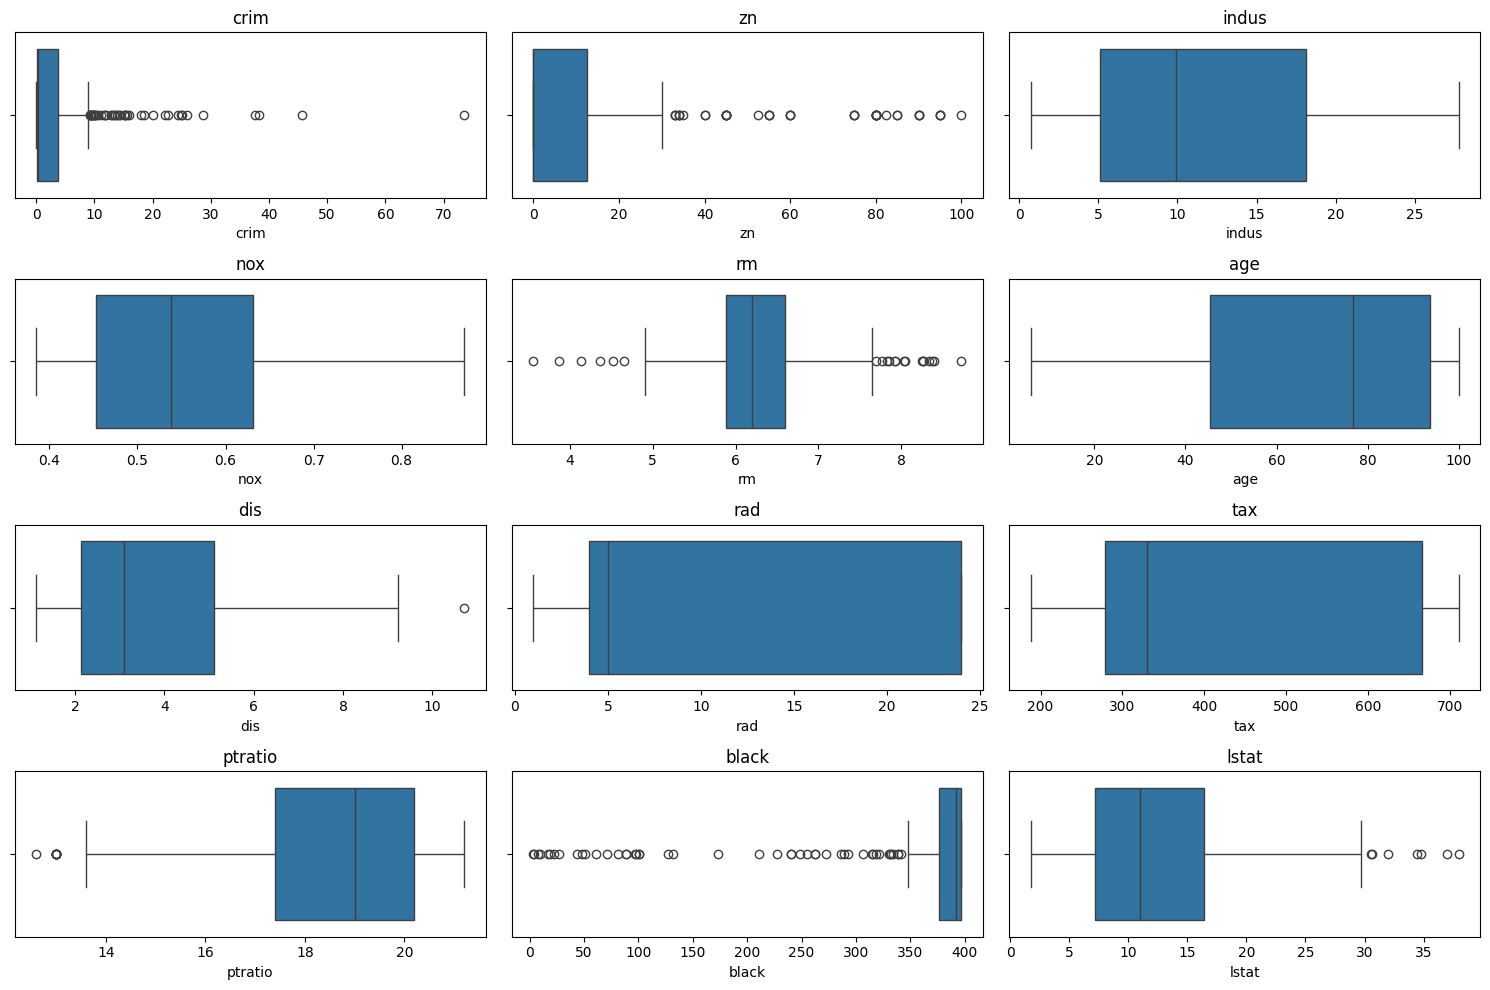

In [274]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(4,3,i)
    sns.boxplot(x=train_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [275]:
## Since the columns are having different numeric ranges, we should do the scaling too

## Part 2 (Model Development)

In [276]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [277]:
## Features and target
X_train_full = train_df.drop(columns= ['ID', 'medv'])
y_train_full = train_df['medv']

In [278]:
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split (
    X_train_full, y_train_full, test_size=0.20, random_state=42) 
## test_size of 0.20 suggests 80 20 split i.e. you are using 80% of the dfata for training and will test on remaining 20 %

In [279]:
train_df.columns

Index(['ID', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad',
       'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='str')

In [280]:
numeric_features = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'black', 'lstat']
categorical_features = ['chas', 'rad' ]

In [281]:
tell_me_about("rad")

'index of accessibility to radial highways.'

In [282]:
numeric_transformer = StandardScaler()

In [283]:
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop  ='first') 
## handle_unknown is important to be ignored, because u might have instances where the type of data say a particular color was absent in the training dataset 
# but might come up in test dataset, so we need to ignore that

In [284]:
# Create the preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

**Difference between fit_transform and transform**

- fit_transform() : Learns parameters from the data (fit) AND applies the transformation. Used on **training data only**. 
    - fit_transform(X_train) learns: mean of each feature, standard deviation and then scales the training data.
    -  fit_transform() = learn + apply,
- transform() : Applies an already-learned transformation. Used on **test or new unseen data**
    - transform(X_test) uses the mean and std from the training data, not from the test data.
    - transform = apply only (using previously learned state)


**Why not use fit_transform on test data?**

Because that would leak information from the test set into the training process (data leakage). The model must not learn anything from the test data.

In [285]:
X_train_processed = preprocessor.fit_transform(X_train_split)
X_test_processed = preprocessor.transform(X_test_split)
# 01:07:51

In [286]:
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (266, 20)
X_test_processed shape: (67, 20)


In [287]:
# TRAIN MODEL USING SGDREGRESSOR
sgd_reg = SGDRegressor(
    max_iter=1000,
    eta0=0.01, # Learning rate
    random_state=42
)

# IN ML ALGO -  we only have fit & predict
## FIT_TRANSOFRM, FIT, TRANSFORM ARE THERE FOPR SCALING, NORMALISATION ETC. 

In Linear Regression, learning can be done in 2 ways: 
- **Gradient Descent** : Here you update the parameters iteratively i.e. there is a lot of computation involved. So it is suitable for medium and large data set so that computation costs make sense. Not ideal for small datasets. This is present in sklearn under SGD Regressor
- **OLS** : This is good for small to medium sized datasets. Here it finds the optimal parameters in a single pass. This is faster and much easier hence it becomes the default model for testing. 

In [288]:
sgd_reg.fit(X_train_processed, y_train_split)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [289]:
# 20 features --> y = MX + C 
# M --> 20m
# C --> 1

sgd_reg.coef_, sgd_reg.intercept_

(array([-0.37793492,  1.44808695, -0.32132364, -1.5279343 ,  2.37526604,
        -0.39357937, -3.52899026, -1.15657335, -1.55039072,  0.69211284,
        -4.38475817,  3.31127451,  0.61052522,  2.96089653,  1.49482397,
         1.75925969,  0.39099955,  2.33406478,  3.64693471,  6.0595485 ]),
 array([19.7992466]))

In [290]:
len(sgd_reg.coef_)

20

In [291]:
# Here we are trying to run using 2 models SGD, OLS. The basic workflow is teh same. 

# Test Model

In [292]:
# With SGD
y_test_pred = sgd_reg.predict(X_test_processed)
y_train_pred = sgd_reg.predict(X_train_processed)

In [293]:
def plot_actual_vs_predicted_lines(y_actual, y_predicted):
    plt.figure(figsize=(14, 7))

    if isinstance(y_actual, pd.Series):
        y_actual = y_actual.values
    
    plt.plot(y_actual, label='Actual Values', color='#1f77b4', linewidth=2)

    plt.plot(y_predicted, label='Predicted Values', color='#ff7f0e', linewidth=2, linestyle='--')
    
    plt.title('Actual vs. Predicted Values Over Index (Trend Comparison)')
    plt.xlabel('Data Index')
    plt.ylabel('Median Home Value')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


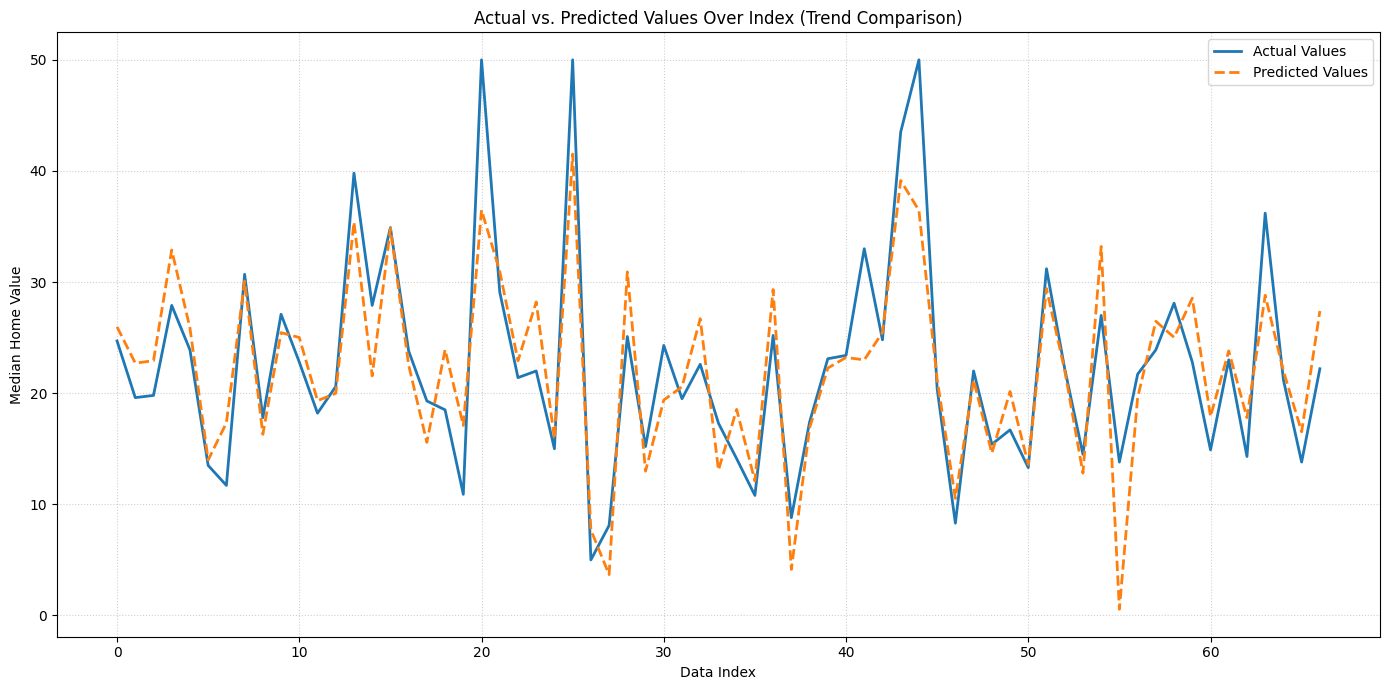

In [294]:
plot_actual_vs_predicted_lines(y_test_split, y_test_pred)

In [295]:
# Evaluation
from sklearn.metrics import mean_squared_error

In [296]:
mse_train = mean_squared_error(y_train_split, y_train_pred)
mse_test = mean_squared_error(y_test_split, y_test_pred)

print(f"MSE (TRAIN) (SGD) : {mse_train}")
print(f"MSE (TEST) (SGD): {mse_test}")

MSE (TRAIN) (SGD) : 22.10430713998983
MSE (TEST) (SGD): 21.34689674174321


# R-squared : A metric of Model Performance

- R-squared tells us how much of the variation in the target variable is explained by the model. Higher is better, but context matters. 
- R-squared is usually is a decimal number refering to a percentage i.e. R-squared of 0.80 means 80 % variance is explained by the model. 
- 0.80 is better than 0.60 R-squared i.e. 0.80 model is better. 

In [297]:
from sklearn.metrics import r2_score

In [298]:
r2_sdg = r2_score(y_test_split, y_test_pred)


print(f"R2 Square (SGD) : {r2_sdg:.2f}")


R2 Square (SGD) : 0.76


## Save Artefacts

you need three components: scaling, encoding, model

In [299]:
import joblib

In [300]:
model_filename = '2.31) Linear_regression_model_SGD_artefacts.joblib'

preprocessor_filename = '2.32) Linear_regression_model_SGD_data_processor_artefacts.joblib'

In [301]:
joblib.dump(sgd_reg, model_filename)
joblib.dump(preprocessor, preprocessor_filename)

['2.32) Linear_regression_model_SGD_data_processor_artefacts.joblib']

In [302]:
print(f"\nModel saved to: {model_filename}")
print(f"Preprocessor saved to: {preprocessor_filename}")


Model saved to: 2.31) Linear_regression_model_SGD_artefacts.joblib
Preprocessor saved to: 2.32) Linear_regression_model_SGD_data_processor_artefacts.joblib
